# Comparative Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
panel = pd.read_csv("../data/processed/main_dataset.csv")
panel.head()

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,undernourishment,co2,health_expenditure_percent,education_expenditure_percent,unemployment,sanitation,injuries,communicable,noncommunicable_disease,life_expectancy_final
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,100,...,21.5,5949.999809,10.105348,3.25580,11.127,NaN,3673696.62,6528888.62,6988545.28,64.1885
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,100,...,20.7,4880.000114,9.528871,3.69522,11.142,NaN,3267937.78,6649335.87,6900348.40,61.4330
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,100,...,20.7,5989.999771,8.805941,3.45446,11.193,NaN,2807904.86,6813189.19,6799914.37,61.2125
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,100,...,21.1,8079.999924,7.897176,3.32000,11.341,NaN,2715550.23,7036448.02,6640268.93,60.7770
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,100,...,20.2,8930.000305,8.561907,3.46201,11.054,NaN,2540038.63,7181018.86,6539124.12,60.3765


## Developed vs Developing

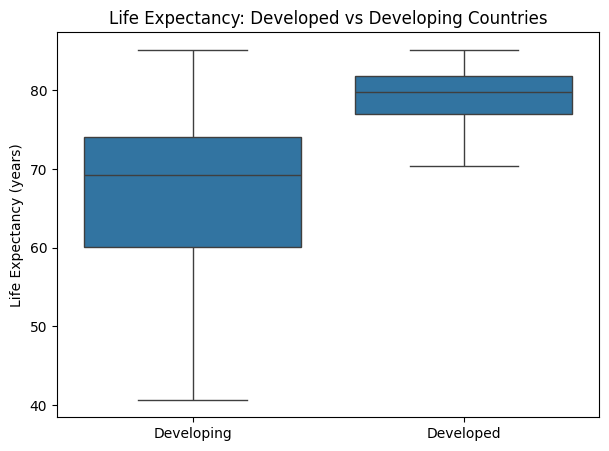

In [2]:
panel.groupby("status")["life_expectancy_final"].describe()
plt.figure(figsize=(7,5))
sns.boxplot(data=panel, x="status", y="life_expectancy_final")
plt.title("Life Expectancy: Developed vs Developing Countries")
plt.ylabel("Life Expectancy (years)")
plt.xlabel("")
plt.show()

In [3]:
panel.groupby("status")["life_expectancy_final"].mean()

status
Developed     79.159502
Developing    66.986219
Name: life_expectancy_final, dtype: float64

A clear disparity exists between developed and developing countries. Developed countries consistently exhibit substantially higher life expectancy levels than developing countries, with both higher medians and narrower variability. The boxplot demonstrates that the majority of developing countries lie below the lower quartile of developed countries, indicating a structural global health gap rather than random variation. This suggests that socioeconomic development is a primary driver of life expectancy and motivates deeper investigation into economic and social predictors in later analysis.

## Income Group Comparison

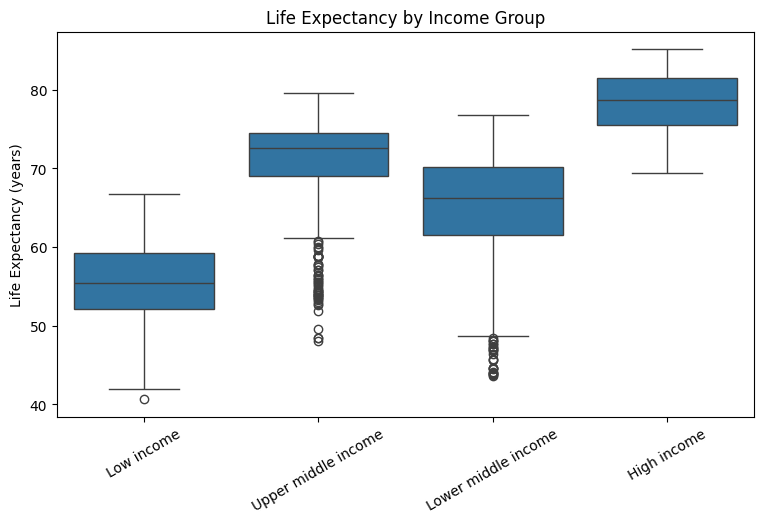

In [4]:
panel.groupby("income_group")["life_expectancy_final"].mean().sort_values()
plt.figure(figsize=(9,5))
sns.boxplot(data=panel, x="income_group", y="life_expectancy_final")
plt.xticks(rotation=30)
plt.title("Life Expectancy by Income Group")
plt.ylabel("Life Expectancy (years)")
plt.xlabel("")
plt.show()

Life expectancy increases monotonically across income groups. Low-income countries exhibit the lowest life expectancy levels, while high-income countries display the highest and most stable outcomes. The consistent ordering across all quartiles indicates a strong relationship between economic development and population health outcomes. This pattern strongly suggests that economic capacity influences healthcare access, nutrition, and public health infrastructure.

## Regional Comparison

In [5]:
region_means = panel.groupby("region")["life_expectancy_final"].mean().sort_values()
region_means

region
Sub-Saharan Africa            56.943371
South Asia                    67.711117
East Asia & Pacific           71.389855
Latin America & Caribbean     73.244935
Middle East & North Africa    74.106052
Europe & Central Asia         76.290846
North America                 81.297561
Name: life_expectancy_final, dtype: float64

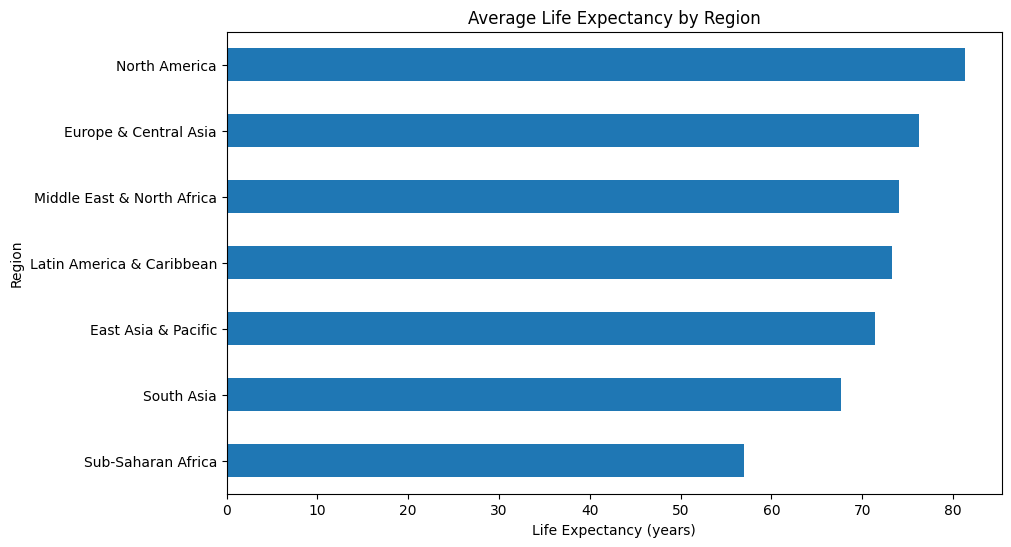

In [6]:
plt.figure(figsize=(10,6))
region_means.plot(kind="barh")
plt.title("Average Life Expectancy by Region")
plt.xlabel("Life Expectancy (years)")
plt.ylabel("Region")
plt.show()

Regional comparisons reveal large geographic inequalities in life expectancy. Regions such as North America or Europe and high-income CEntral Asia exhibit the highest average life expectancy, while Sub-Saharan Africa and parts of South Asia show substantially lower values. This indicates that geographic and structural factors including healthcare infrastructure, disease burden, and economic development significantly affect population longevity.

## Time Trend

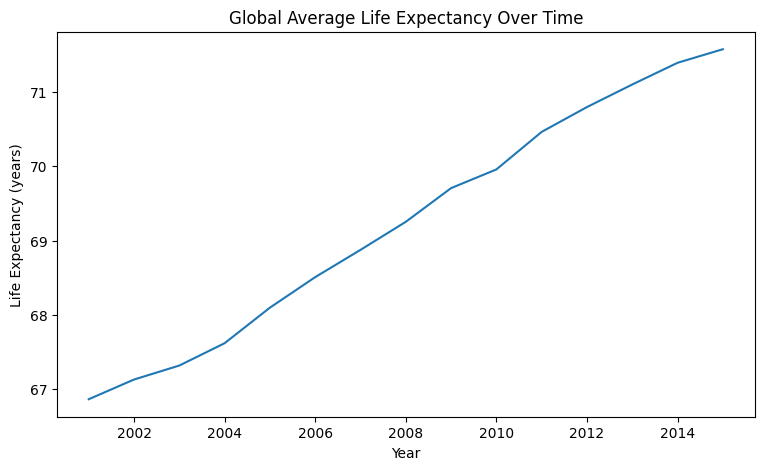

In [7]:
yearly = panel.groupby("year")["life_expectancy_final"].mean()
plt.figure(figsize=(9,5))
yearly.plot()
plt.title("Global Average Life Expectancy Over Time")
plt.ylabel("Life Expectancy (years)")
plt.xlabel("Year")
plt.show()

Global life expectancy shows a clear upward trend over time, indicating sustained long-term improvements in health outcomes worldwide. Despite regional inequalities, the overall trajectory is positive, reflecting advancements in medicine, sanitation, vaccination, and public health policy. However, the persistence of large cross-country variation suggests that improvements have not been evenly distributed.

## Developed vs Developing Over Time

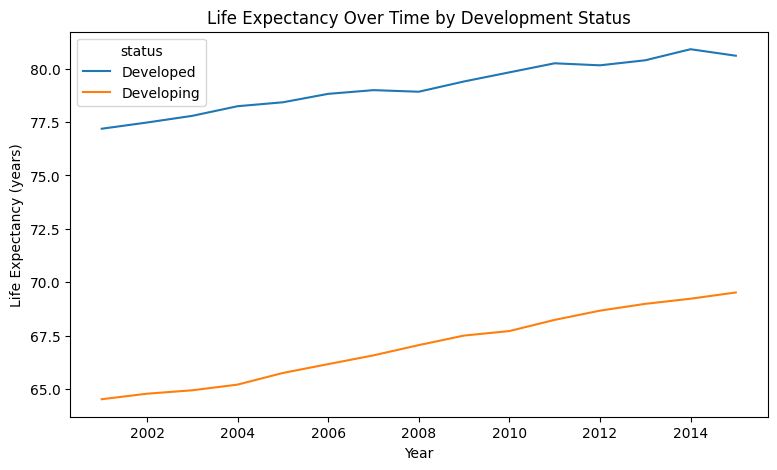

In [8]:
status_year = panel.groupby(["year","status"])["life_expectancy_final"].mean().reset_index()

plt.figure(figsize=(9,5))
sns.lineplot(data=status_year, x="year", y="life_expectancy_final", hue="status")
plt.title("Life Expectancy Over Time by Development Status")
plt.ylabel("Life Expectancy (years)")
plt.xlabel("Year")
plt.show()


Both developed and developing countries have experienced improvements in life expectancy over time; however, the gap between them remains persistent. While developing countries show gradual and steeper progress, they do not converge fully with developed countries, suggesting structural barriers to health improvement beyond simple time trends.